# REGRESSÃO PARA DADOS DE CONTAGENS

Improtando bibliotecas

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial
from scipy.stats import chi2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# Suprimir warnings específicos
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

sns.set(style="whitegrid")

Leitura da base de dados

In [2]:
fragmentos = pd.read_excel('fragmentos.xlsx')

In [3]:
fragmentos.head()

,locality,site,Riqueza_obs,Riqueza_HB,Bsc,Dne,Dnm,Dnn,Dns,Hal,...,depth,forcov,forcov2,forcov10,dfrag,dfrag2,dwater,dwater2,X,Y
0,MAC,MacAc1,3,6,0,0,0,0,0,0,...,-1.232668,-0.604596,-0.672774,-6.045965,0.410084,0.166782,1.198175,1.166645,-49.9376,-20.7408
1,MAC,MacAc2,11,13,1,0,1,1,0,0,...,0.821168,-0.020849,-0.152952,-0.208489,-0.097045,-0.381401,0.970207,0.864035,-49.9353,-20.7410
2,MAC,MacAc3,10,12,1,0,0,0,0,0,...,-0.704539,-0.013816,-0.146124,-0.138159,-1.242271,-1.059858,-0.121245,-0.299232,-49.9348,-20.7419
3,MAC,MacAc4,10,13,1,1,1,1,0,1,...,0.821168,-0.171663,-0.296136,-1.716633,-1.242271,-1.059858,-0.087507,-0.270350,-49.9334,-20.7462
4,MAC,MacAc5,3,6,0,0,0,0,0,0,...,-1.306019,0.203364,0.071358,2.033643,-0.471888,-0.688845,0.162610,-0.042156,-49.9270,-20.7453


A base contém 40 colunas.
As preditoras já estão padronizadas( média 0 e desvio padrão 1).
As variáveis com "2" indicam variáveis quadráticas (podem ser usadas para se testar relações não lineares).
Também temos a riqueza observada e a estimada (Riqueza_HB) e as coordenadas geográficas (X e Y).

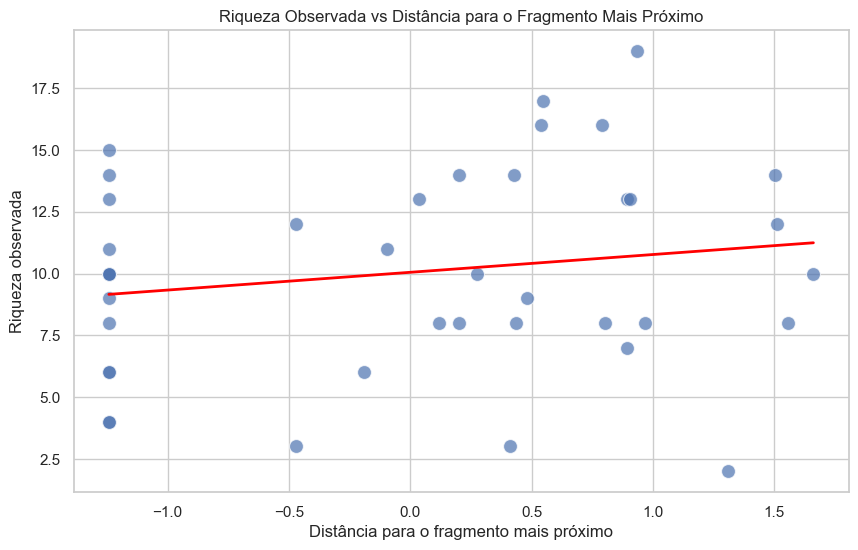

In [4]:
# Visualização das variáveis
plt.figure(figsize=(10, 6))
sns.scatterplot(x='dfrag', y='Riqueza_obs', data=fragmentos, s=100, alpha=0.7)
sns.regplot(x='dfrag', y='Riqueza_obs', data=fragmentos, scatter=False, ci=None, color='red', line_kws={'lw': 2})
plt.xlabel('Distância para o fragmento mais próximo')
plt.ylabel('Riqueza observada')
plt.title('Riqueza Observada vs Distância para o Fragmento Mais Próximo')
plt.show()

## Ajustando modelos de Poisson , Binomial Negativa e Quasi-Poisson

**Modelo de Poisson** 

In [5]:
mod_pois = sm.GLM(fragmentos['Riqueza_obs'], sm.add_constant(fragmentos['dfrag']), family=sm.families.Poisson()).fit()

In [6]:
results = mod_pois
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            Riqueza_obs   No. Observations:                   40
Model:                            GLM   Df Residuals:                       38
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -115.64
Date:                Wed, 11 Mar 2026   Deviance:                       68.856
Time:                        18:57:24   Pearson chi2:                     63.0
No. Iterations:                     4   Pseudo R-squ. (CS):            0.04905
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3051      0.050     46.101      0.000       2.207       2.403
dfrag          0.0718      0.051      1.416      0.157      -0.028       0.171
==============================================================================
"""

# Validação dos Modelos de Contagem

Agora vamos avaliar a qualidade dos modelos de contagem ajustados. Utilizaremos métricas clássicas como AIC, BIC, Deviance e Pseudo-R², além do teste de razão de verossimilhança (Likelihood Ratio Test). Esses testes ajudam a verificar se o modelo está bem ajustado aos dados.

In [7]:
# Resultados principais
print('AIC:', results.aic)
print('BIC:', results.bic)
print('Deviance:', results.deviance)

AIC: 235.28799322033197
BIC: -71.32178785552532
Deviance: 68.85563140080427


### Teste de Razão de Verossimilhança (Likelihood Ratio Test)

Este teste compara o modelo ajustado com o modelo nulo (sem variáveis explicativas). Se o p-valor for baixo, rejeitamos a hipótese nula e concluímos que o modelo explicativo é melhor que o modelo sem variáveis.

In [8]:
LR = 2 * (results.llf - results.llnull)
df = results.df_model
pval = stats.chi2.sf(LR, df)
print('LR Statistic:', LR)
print('Degrees of Freedom:', df)
print('p-value:', pval)

LR Statistic: 2.0119306004268935
Degrees of Freedom: 1
p-value: 0.1560666058277015


**Modelo de Binomial Negativa**

In [9]:
mod_nb = NegativeBinomial(fragmentos['Riqueza_obs'], sm.add_constant(fragmentos['dfrag'])).fit()

Optimization terminated successfully.
         Current function value: 2.821005
         Iterations: 9
         Function evaluations: 12
         Gradient evaluations: 12


In [10]:
results = mod_nb
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:            Riqueza_obs   No. Observations:                   40
Model:               NegativeBinomial   Df Residuals:                       38
Method:                           MLE   Df Model:                            1
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                0.005235
Time:                        18:57:24   Log-Likelihood:                -112.84
converged:                       True   LL-Null:                       -113.43
Covariance Type:            nonrobust   LLR p-value:                    0.2758
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3050      0.065     35.567      0.000       2.178       2.432
dfrag          0.0725      0.066      1.098      0.272      -0.057       0.202
alpha          0.0680      0.040      1.705      0.088      -0.010       0.146
==============================================================================
"""

# Validação dos Modelos de Contagem

Agora vamos avaliar a qualidade dos modelos de contagem ajustados. Utilizaremos métricas clássicas como AIC, BIC, Deviance e Pseudo-R², além do teste de razão de verossimilhança (Likelihood Ratio Test). Esses testes ajudam a verificar se o modelo está bem ajustado aos dados.

In [11]:
# Resultados principais
print('AIC:', results.aic)
print('BIC:', results.bic)
##print('Deviance:', results.deviance)

AIC: 231.68041776651617
BIC: 236.747056128858


### Teste de Razão de Verossimilhança (Likelihood Ratio Test)

Este teste compara o modelo ajustado com o modelo nulo (sem variáveis explicativas). Se o p-valor for baixo, rejeitamos a hipótese nula e concluímos que o modelo explicativo é melhor que o modelo sem variáveis.

In [12]:
LR = 2 * (results.llf - results.llnull)
df = results.df_model
pval = stats.chi2.sf(LR, df)
print('LR Statistic:', LR)
print('Degrees of Freedom:', df)
print('p-value:', pval)

LR Statistic: 1.187687133558967
Degrees of Freedom: 1.0
p-value: 0.2757965857513457


**Modelo de Quasi-Poisson**

O statsmodels não tem um GLM Quasi-Poisson direto, então ajustaremos o modelo Poisson e corrigiremos a sobredispersão manualmente

In [13]:
mod_quasipois = sm.GLM(fragmentos['Riqueza_obs'], sm.add_constant(fragmentos['dfrag']), family=sm.families.Poisson()).fit()
quasi_dispersion = np.sum(mod_quasipois.resid_pearson**2) / mod_quasipois.df_resid

In [14]:
results = mod_quasipois
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            Riqueza_obs   No. Observations:                   40
Model:                            GLM   Df Residuals:                       38
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -115.64
Date:                Wed, 11 Mar 2026   Deviance:                       68.856
Time:                        18:57:24   Pearson chi2:                     63.0
No. Iterations:                     4   Pseudo R-squ. (CS):            0.04905
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3051      0.050     46.101      0.000       2.207       2.403
dfrag          0.0718      0.051      1.416      0.157      -0.028       0.171
==============================================================================
"""

# Validação dos Modelos de Contagem

Agora vamos avaliar a qualidade dos modelos de contagem ajustados. Utilizaremos métricas clássicas como AIC, BIC, Deviance e Pseudo-R², além do teste de razão de verossimilhança (Likelihood Ratio Test). Esses testes ajudam a verificar se o modelo está bem ajustado aos dados.

In [15]:
# Resultados principais
print('AIC:', results.aic)
print('BIC:', results.bic)
print('Deviance:', results.deviance)

AIC: 235.28799322033197
BIC: -71.32178785552532
Deviance: 68.85563140080427


### Teste de Razão de Verossimilhança (Likelihood Ratio Test)

Este teste compara o modelo ajustado com o modelo nulo (sem variáveis explicativas). Se o p-valor for baixo, rejeitamos a hipótese nula e concluímos que o modelo explicativo é melhor que o modelo sem variáveis.

In [16]:
LR = 2 * (results.llf - results.llnull)
df = results.df_model
pval = stats.chi2.sf(LR, df)
print('LR Statistic:', LR)
print('Degrees of Freedom:', df)
print('p-value:', pval)

LR Statistic: 2.0119306004268935
Degrees of Freedom: 1
p-value: 0.1560666058277015


Funções para calcular resíduos deviance e Pearson

In [17]:
def calc_residuos_deviance(y, y_pred):
    y_pred = np.clip(y_pred, 1e-10, None)
    deviance_residuals = 2 * (y * np.log(y / y_pred) - (y - y_pred))
    return deviance_residuals

def calc_residuos_pearson(y, y_pred):
    y_pred = np.clip(y_pred, 1e-10, None)
    return (y - y_pred) / np.sqrt(y_pred)

Calcular resíduos para o modelo Poisson

In [18]:
residuos_deviance_pois = calc_residuos_deviance(fragmentos['Riqueza_obs'], mod_pois.fittedvalues)
residuos_pearson_pois = calc_residuos_pearson(fragmentos['Riqueza_obs'], mod_pois.fittedvalues)

Calcular resíduos para o modelo Binomial Negativa

In [19]:
residuos_deviance_nb = calc_residuos_deviance(fragmentos['Riqueza_obs'], mod_nb.fittedvalues)
residuos_pearson_nb = calc_residuos_pearson(fragmentos['Riqueza_obs'], mod_nb.fittedvalues)

Calcular resíduos para o modelo Quasi-Poisson

In [20]:
residuos_deviance_quasipois = calc_residuos_deviance(fragmentos['Riqueza_obs'], mod_quasipois.fittedvalues) / np.sqrt(quasi_dispersion)
residuos_pearson_quasipois = calc_residuos_pearson(fragmentos['Riqueza_obs'], mod_quasipois.fittedvalues) / np.sqrt(quasi_dispersion)

***Análise de resíduos***

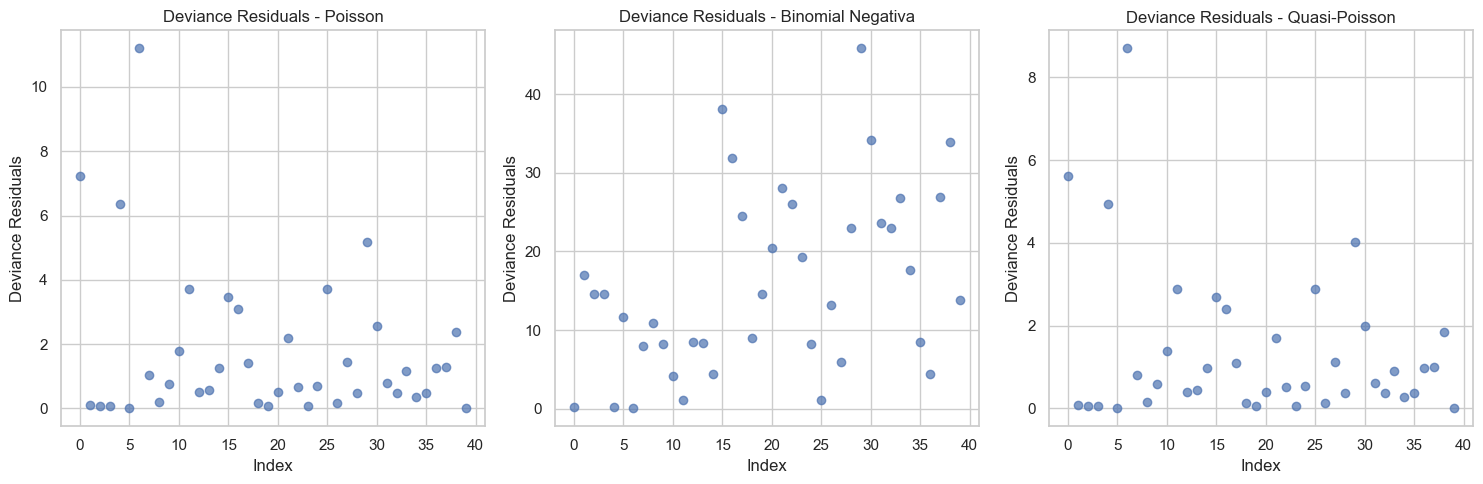

In [21]:
# Plotar resíduos deviance
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(range(len(residuos_deviance_pois)), residuos_deviance_pois, alpha=0.7)
#plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Index')
plt.ylabel('Deviance Residuals')
plt.title('Deviance Residuals - Poisson')

plt.subplot(1, 3, 2)
plt.scatter(range(len(residuos_deviance_nb)), residuos_deviance_nb, alpha=0.7)
#plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Index')
plt.ylabel('Deviance Residuals')
plt.title('Deviance Residuals - Binomial Negativa')

plt.subplot(1, 3, 3)
plt.scatter(range(len(residuos_deviance_quasipois)), residuos_deviance_quasipois, alpha=0.7)
#plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Index')
plt.ylabel('Deviance Residuals')
plt.title('Deviance Residuals - Quasi-Poisson')

plt.tight_layout()
plt.show()


**Coeficiente de Sobredispersão (Ratio):**

Próximo de 1: Indica que não há sobredispersão significativa e o modelo de Poisson pode ser adequado.
Maior que 1: Indica sobredispersão. A variância observada é maior que a esperada pelo modelo de Poisson.
Menor que 1: Indica subdispersão, embora menos comum.

**p-Valor:**

Menor que 0.05: Rejeitamos a hipótese nula de que não há sobredispersão, indicando que a sobredispersão é significativa.
Maior ou igual a 0.05: Não rejeitamos a hipótese nula, indicando que a sobredispersão não é significativa.

In [22]:
# Analisar overdispersion
def test_overdispersion(model, dispersion_ratio=None):
    chisq = sum(model.resid_pearson**2)
    if dispersion_ratio is not None:
        chisq /= dispersion_ratio
    ratio = chisq / model.df_resid
    p_value = 1 - chi2.cdf(chisq, model.df_resid)
    return ratio, p_value

In [23]:
# Overdispersion para modelo Poisson
ratio_pois, p_value_pois = test_overdispersion(mod_pois)
print(f"Overdispersion test for Poisson: ratio={ratio_pois}, p-value={p_value_pois}")

Overdispersion test for Poisson: ratio=1.6566095075674707, p-value=0.006659918428787437


In [24]:
# Overdispersion para modelo Binomial Negativa
ratio_nb, p_value_nb = test_overdispersion(mod_nb)
print(f"Overdispersion test for Negative Binomial: ratio={ratio_nb}, p-value={p_value_nb}")

Overdispersion test for Negative Binomial: ratio=0.9813054246657614, p-value=0.5021206415109118


In [25]:
# Overdispersion para modelo Quasi-Poisson
ratio_quasipois, p_value_quasipois = test_overdispersion(mod_quasipois, dispersion_ratio=quasi_dispersion)
print(f"Overdispersion test for Quasi-Poisson: ratio={ratio_quasipois:.2f}, p-value={p_value_quasipois:.2f}")

Overdispersion test for Quasi-Poisson: ratio=1.00, p-value=0.47


## Comparação entre diferentes Modelos de Contagem

Agora vamos comparar os principais modelos usados em dados de contagem:
- **Poisson**
- **Binomial Negativa**


A comparação será feita a partir do AIC.

In [26]:
models = {
    'Poisson': mod_pois,
    'Binomial Negativa': mod_nb,
}

for name, m in models.items():
    print(f'--- {name} ---')
    print('AIC:', m.aic)
    print()

--- Poisson ---
AIC: 235.28799322033197

--- Binomial Negativa ---
AIC: 231.68041776651617

